# Pandas — Análisis y Manipulación de Datos

## ¿Qué es Pandas?

**Pandas** es la librería más utilizada para análisis y manipulación de datos en Python. Su nombre viene de **Pan**el **Da**ta (datos de panel), un término de econometría.

Pandas introduce dos estructuras de datos fundamentales:

| Estructura | Descripción | Analogía |
|---|---|---|
| **Series** | Arreglo unidimensional con etiquetas | Una columna de Excel |
| **DataFrame** | Tabla bidimensional con filas y columnas | Una hoja de Excel |

## ¿Para qué sirve?

- Leer y escribir datos (CSV, Excel, SQL, JSON, etc.)
- Limpiar datos (manejar valores nulos, duplicados, errores)
- Filtrar, ordenar y agrupar datos
- Calcular estadísticas y resúmenes
- Preparar datos para visualización o machine learning

## Instalación e Importación

```bash
pip install pandas
```

Por convención, se importa con el alias `pd`:

In [47]:
import pandas as pd
import numpy as np  # Pandas y NumPy se usan frecuentemente juntos

print("Pandas versión:", pd.__version__)

Pandas versión: 3.0.2


---
## Nivel 1 — Series

In [48]:
# Crear una Serie desde una lista
temperaturas = pd.Series([25.1, 27.3, 24.8, 28.5, 26.0])
print("Serie de temperaturas:")
print(temperaturas)
print("\nTipo:", type(temperaturas))

Serie de temperaturas:
0    25.1
1    27.3
2    24.8
3    28.5
4    26.0
dtype: float64

Tipo: <class 'pandas.Series'>


In [49]:
# Serie con índices personalizados (etiquetas)
dias = pd.Series(
    [25.1, 27.3, 24.8, 28.5, 26.0],
    index=["Lunes", "Martes", "Miércoles", "Jueves", "Viernes"]
)
print("Temperatura por día:")
print(dias)

print("\nTemperatura del Martes:", dias["Martes"])
print("Promedio de la semana:", dias.mean())

Temperatura por día:
Lunes        25.1
Martes       27.3
Miércoles    24.8
Jueves       28.5
Viernes      26.0
dtype: float64

Temperatura del Martes: 27.3
Promedio de la semana: 26.339999999999996


In [50]:
# Métodos estadísticos de una Serie (§8.1)
s = pd.Series([-0.3, 0.4, 3.9, 7.4, 12.0, 15.0, 17.2,
               16.8, 13.1, 9.1, 3.7, 0.8], name='temp_C')

print('mean:', s.mean())
print('min:', s.min())
print('standard deviation:', s.std())
print('index of max element:', s.argmax())
print('values as list:', s.values)
print('indices of sorted Series:', s.argsort().values)
print('cumulative sum:', s.cumsum().values)

mean: 8.258333333333333
min: -0.3
standard deviation: 6.520242373260415
index of max element: 6
values as list: [-0.3  0.4  3.9  7.4 12.  15.  17.2 16.8 13.1  9.1  3.7  0.8]
indices of sorted Series: [ 0  1 11 10  2  3  9  4  8  5  7  6]
cumulative sum: [-0.3  0.1  4.  11.4 23.4 38.4 55.6 72.4 85.5 94.6 98.3 99.1]


In [51]:
# Índice con etiquetas — set_axis() (§8.1)
s2 = s.set_axis(['jan', 'feb', 'mar', 'apr', 'may', 'jun',
                 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])
print(s2)
print("\nTemperatura en octubre:", s2['oct'])

jan    -0.3
feb     0.4
mar     3.9
apr     7.4
may    12.0
jun    15.0
jul    17.2
aug    16.8
sep    13.1
oct     9.1
nov     3.7
dec     0.8
Name: temp_C, dtype: float64

Temperatura en octubre: 9.1


---
## Nivel 2 — DataFrames

### Crear un DataFrame

In [52]:
# Crear DataFrame desde un diccionario
datos = {
    "Nombre":   ["Ana", "Carlos", "Diana", "Eduardo", "Fátima"],
    "Edad":     [20, 22, 21, 23, 20],
    "Carrera":  ["Física", "Matemática", "Física", "Computación", "Matemática"],
    "Promedio": [85.5, 72.0, 91.3, 68.7, 79.2]
}

df = pd.DataFrame(datos)
print(df)

    Nombre  Edad      Carrera  Promedio
0      Ana    20       Física      85.5
1   Carlos    22   Matemática      72.0
2    Diana    21       Física      91.3
3  Eduardo    23  Computación      68.7
4   Fátima    20   Matemática      79.2


In [53]:
# Información básica del DataFrame
print("Forma (filas x columnas):", df.shape)
print("\nNombres de columnas:", df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)

Forma (filas x columnas): (5, 4)

Nombres de columnas: ['Nombre', 'Edad', 'Carrera', 'Promedio']

Tipos de datos:
Nombre          str
Edad          int64
Carrera         str
Promedio    float64
dtype: object


In [54]:
# Resumen estadístico automático
print("Estadísticas descriptivas:")
df.describe()

Estadísticas descriptivas:


,Edad,Promedio
count,5.00000,5.000000
mean,21.20000,79.340000
std,1.30384,9.328612
min,20.00000,68.700000
25%,20.00000,72.000000
50%,21.00000,79.200000
75%,22.00000,85.500000
max,23.00000,91.300000


In [55]:
# head(), tail() y atributos del índice (§8.2.1)
df_clima = pd.DataFrame({
    'temp_C':  [-0.3, 0.4, 3.9, 7.4, 12.0, 15.0,
                17.2, 16.8, 13.1, 9.1, 3.7, 0.8],
    'rain_mm': [59, 57, 84, 100, 143, 153, 172, 164, 135, 89, 88, 80]
}, index=['jan','feb','mar','apr','may','jun',
          'jul','aug','sep','oct','nov','dec'])

print("Primeras 3 filas:")
print(df_clima.head(3))
print("\nÚltimas 2 filas:")
print(df_clima.tail(2))
print("\nColumnas:", df_clima.columns.tolist())
print("Índice (list):", list(df_clima.index))

Primeras 3 filas:
     temp_C  rain_mm
jan    -0.3       59
feb     0.4       57
mar     3.9       84

Últimas 2 filas:
     temp_C  rain_mm
nov     3.7       88
dec     0.8       80

Columnas: ['temp_C', 'rain_mm']
Índice (list): ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']


### Acceder a datos

In [56]:
# Acceder a una columna
print("Columna 'Nombre':")
print(df["Nombre"])

print("\nColumnas 'Nombre' y 'Promedio':")
print(df[["Nombre", "Promedio"]])

Columna 'Nombre':
0        Ana
1     Carlos
2      Diana
3    Eduardo
4     Fátima
Name: Nombre, dtype: str

Columnas 'Nombre' y 'Promedio':
    Nombre  Promedio
0      Ana      85.5
1   Carlos      72.0
2    Diana      91.3
3  Eduardo      68.7
4   Fátima      79.2


In [57]:
# Acceder a filas con .iloc (por posición numérica)
print("Primera fila (iloc[0]):")
print(df.iloc[0])

print("\nFilas 1 a 3 (iloc[1:4]):")
print(df.iloc[1:4])

Primera fila (iloc[0]):
Nombre         Ana
Edad            20
Carrera     Física
Promedio      85.5
Name: 0, dtype: object

Filas 1 a 3 (iloc[1:4]):
    Nombre  Edad      Carrera  Promedio
1   Carlos    22   Matemática      72.0
2    Diana    21       Física      91.3
3  Eduardo    23  Computación      68.7


In [58]:
# Acceder a filas con .loc (por etiqueta/índice)
print("Fila con índice 2:")
print(df.loc[2])

# Acceder a un valor específico: fila 0, columna 'Nombre'
print("\nValor en fila 0, columna 'Nombre':", df.loc[0, "Nombre"])

Fila con índice 2:
Nombre       Diana
Edad            21
Carrera     Física
Promedio      91.3
Name: 2, dtype: object

Valor en fila 0, columna 'Nombre': Ana


### `loc` avanzado — selección por etiqueta (§8.2.2)

In [59]:
# loc con lista de etiquetas (§8.2.2)
print("Marzo, abril y junio:")
print(df_clima.loc[['mar', 'apr', 'jun']])

Marzo, abril y junio:
     temp_C  rain_mm
mar     3.9       84
apr     7.4      100
jun    15.0      153


In [60]:
# loc con slice de etiquetas — el extremo final SÍ se incluye (§8.2.2)
print("De marzo a mayo:")
print(df_clima.loc['mar':'may'])

De marzo a mayo:
     temp_C  rain_mm
mar     3.9       84
apr     7.4      100
may    12.0      143


In [61]:
# loc combinando filas Y columnas: df.loc[<filas>, <columnas>] (§8.2.2)
print("Lluvia de mayo a septiembre:")
print(df_clima.loc['may':'sep', 'rain_mm'])

print("\nTotal de lluvia en verano:", df_clima.loc['may':'sep', 'rain_mm'].sum())

Lluvia de mayo a septiembre:
may    143
jun    153
jul    172
aug    164
sep    135
Name: rain_mm, dtype: int64

Total de lluvia en verano: 767


In [62]:
# Máscara booleana con loc (§8.2.2)
# Temperatura en meses con lluvia < 100 mm
print("Temp en meses con lluvia < 100 mm:")
print(df_clima.loc[df_clima['rain_mm'] < 100, 'temp_C'])

Temp en meses con lluvia < 100 mm:
jan   -0.3
feb    0.4
mar    3.9
oct    9.1
nov    3.7
dec    0.8
Name: temp_C, dtype: float64


---
## Nivel 3 — Filtrado, Ordenamiento y Nuevas Columnas

### Filtrar filas con condiciones

In [63]:
# Estudiantes con promedio mayor a 75
buenos = df[df["Promedio"] > 75]
print("Estudiantes con promedio > 75:")
print(buenos)

print()

# Estudiantes de Física
fisica = df[df["Carrera"] == "Física"]
print("Estudiantes de Física:")
print(fisica)

Estudiantes con promedio > 75:
   Nombre  Edad     Carrera  Promedio
0     Ana    20      Física      85.5
2   Diana    21      Física      91.3
4  Fátima    20  Matemática      79.2

Estudiantes de Física:
  Nombre  Edad Carrera  Promedio
0    Ana    20  Física      85.5
2  Diana    21  Física      91.3


In [64]:
# Condiciones múltiples
# & = AND,  | = OR
filtro = df[(df["Promedio"] > 70) & (df["Edad"] <= 21)]
print("Promedio > 70 Y Edad <= 21:")
print(filtro)

Promedio > 70 Y Edad <= 21:
   Nombre  Edad     Carrera  Promedio
0     Ana    20      Física      85.5
2   Diana    21      Física      91.3
4  Fátima    20  Matemática      79.2


### Ordenar datos

In [65]:
# Ordenar por promedio (descendente)
ranking = df.sort_values("Promedio", ascending=False)
print("Ranking por promedio:")
print(ranking[["Nombre", "Promedio"]])

Ranking por promedio:
    Nombre  Promedio
2    Diana      91.3
0      Ana      85.5
4   Fátima      79.2
1   Carlos      72.0
3  Eduardo      68.7


### Agregar nuevas columnas

In [66]:
# Agregar columna calculada
df["Estado"] = df["Promedio"].apply(lambda p: "Aprobado" if p >= 70 else "Reprobado")
df["Puntos_extra"] = (df["Promedio"] - 70).clip(lower=0).round(1)

print(df)

    Nombre  Edad      Carrera  Promedio     Estado  Puntos_extra
0      Ana    20       Física      85.5   Aprobado          15.5
1   Carlos    22   Matemática      72.0   Aprobado           2.0
2    Diana    21       Física      91.3   Aprobado          21.3
3  Eduardo    23  Computación      68.7  Reprobado           0.0
4   Fátima    20   Matemática      79.2   Aprobado           9.2


### Modificar datos y combinar DataFrames (§8.2.3)

`df.assign()` crea columnas nuevas de forma funcional sin modificar el original.

In [67]:
# assign() — agregar columna con función (§8.2.3)
def celsius_a_f(df):
    return df['temp_C'] * 1.8 + 32

df_clima_f = df_clima.assign(temp_F=celsius_a_f)
print(df_clima_f.head())

     temp_C  rain_mm  temp_F
jan    -0.3       59   31.46
feb     0.4       57   32.72
mar     3.9       84   39.02
apr     7.4      100   45.32
may    12.0      143   53.60


In [68]:
# pd.concat() — combinar filas (§8.2.3)
df_anual = pd.DataFrame({
    'temp_C':  [9.7, 9.5, 9.9],
    'rain_mm': [165.8, 146.1, 139.2]
}, index=['2020', '2019', '2018'])

df_ext = pd.concat([df_clima, df_anual])
print(df_ext)

      temp_C  rain_mm
jan     -0.3     59.0
feb      0.4     57.0
mar      3.9     84.0
apr      7.4    100.0
may     12.0    143.0
jun     15.0    153.0
jul     17.2    172.0
aug     16.8    164.0
sep     13.1    135.0
oct      9.1     89.0
nov      3.7     88.0
dec      0.8     80.0
2020     9.7    165.8
2019     9.5    146.1
2018     9.9    139.2


In [69]:
# pd.concat() con axis=1 — combinar columnas (§8.2.3)
df_minmax = pd.DataFrame({
    'temp_min_C': [-1.9, -2.5, 0.6, 3.5, 7.8, 11.0,
                   13.1, 13.0, 9.7, 6.2, 1.0, -3.0],
    'temp_max_C': [2.5, 3.3, 7.3, 11.5, 16.3, 19.2,
                   21.6, 20.9, 16.8, 12.3, 6.5, 3.5]
}, index=df_clima.index)

df_completo = pd.concat([df_clima, df_minmax], axis=1)
print(df_completo)

     temp_C  rain_mm  temp_min_C  temp_max_C
jan    -0.3       59        -1.9         2.5
feb     0.4       57        -2.5         3.3
mar     3.9       84         0.6         7.3
apr     7.4      100         3.5        11.5
may    12.0      143         7.8        16.3
jun    15.0      153        11.0        19.2
jul    17.2      172        13.1        21.6
aug    16.8      164        13.0        20.9
sep    13.1      135         9.7        16.8
oct     9.1       89         6.2        12.3
nov     3.7       88         1.0         6.5
dec     0.8       80        -3.0         3.5


---
## Nivel 4 — Agrupaciones y Agregaciones

In [70]:
# groupby: agrupar por una columna y calcular estadísticas
por_carrera = df.groupby("Carrera")["Promedio"].agg(["mean", "min", "max", "count"])
por_carrera.columns = ["Promedio_medio", "Mínimo", "Máximo", "Estudiantes"]

print("Estadísticas por carrera:")
print(por_carrera.round(2))

Estadísticas por carrera:
             Promedio_medio  Mínimo  Máximo  Estudiantes
Carrera                                                 
Computación            68.7    68.7    68.7            1
Física                 88.4    85.5    91.3            2
Matemática             75.6    72.0    79.2            2


---
## Nivel 5 — Manejo de Datos Faltantes

In [71]:
# Crear DataFrame con datos faltantes (NaN = Not a Number)
datos_incompletos = pd.DataFrame({
    "Nombre":   ["Ana", "Carlos", "Diana", "Eduardo", "Fátima"],
    "Nota1":    [85, np.nan, 90, 72, np.nan],
    "Nota2":    [78, 65, np.nan, 80, 88],
    "Nota3":    [92, 71, 85, np.nan, 76]
})

print("DataFrame con valores faltantes:")
print(datos_incompletos)
print("\nCantidad de nulos por columna:")
print(datos_incompletos.isnull().sum())

DataFrame con valores faltantes:
    Nombre  Nota1  Nota2  Nota3
0      Ana   85.0   78.0   92.0
1   Carlos    NaN   65.0   71.0
2    Diana   90.0    NaN   85.0
3  Eduardo   72.0   80.0    NaN
4   Fátima    NaN   88.0   76.0

Cantidad de nulos por columna:
Nombre    0
Nota1     2
Nota2     1
Nota3     1
dtype: int64


In [72]:
# Opción 1: Rellenar con la media de la columna
df_rellenado = datos_incompletos.copy()
for col in ["Nota1", "Nota2", "Nota3"]:
    df_rellenado[col] = df_rellenado[col].fillna(df_rellenado[col].mean())

print("Después de rellenar con la media:")
print(df_rellenado.round(1))

Después de rellenar con la media:
    Nombre  Nota1  Nota2  Nota3
0      Ana   85.0   78.0   92.0
1   Carlos   82.3   65.0   71.0
2    Diana   90.0   77.8   85.0
3  Eduardo   72.0   80.0   81.0
4   Fátima   82.3   88.0   76.0


In [73]:
# Opción 2: Eliminar filas con datos faltantes
df_limpio = datos_incompletos.dropna()
print("Después de eliminar filas con nulos:")
print(df_limpio)

Después de eliminar filas con nulos:
  Nombre  Nota1  Nota2  Nota3
0    Ana   85.0   78.0   92.0


### `isna()`, `fillna()` e `interpolate()` (§8.2.4)

In [74]:
# isna() / notna() — mapa de valores faltantes (§8.2.4)
print("Mapa de NaN:")
print(datos_incompletos.isna())

print("\nTotal de NaN por columna:")
print(datos_incompletos.isna().sum())

Mapa de NaN:
   Nombre  Nota1  Nota2  Nota3
0   False  False  False  False
1   False   True  False  False
2   False  False   True  False
3   False  False  False   True
4   False   True  False  False

Total de NaN por columna:
Nombre    0
Nota1     2
Nota2     1
Nota3     1
dtype: int64


In [75]:
# fillna con la media de cada columna (§8.2.4)
df_relleno2 = datos_incompletos.copy()
df_relleno2 = df_relleno2.fillna(
    df_relleno2.mean(axis=0, numeric_only=True)
)
print("Rellenado con la media de cada columna:")
print(df_relleno2.round(1))

Rellenado con la media de cada columna:
    Nombre  Nota1  Nota2  Nota3
0      Ana   85.0   78.0   92.0
1   Carlos   82.3   65.0   71.0
2    Diana   90.0   77.8   85.0
3  Eduardo   72.0   80.0   81.0
4   Fátima   82.3   88.0   76.0


In [76]:
# interpolate() — interpolación lineal (§8.2.4)
s_nan = pd.Series([1.0, np.nan, 3.0, np.nan, 5.0])
print("Original:", s_nan.values)
print("Interpolado:", s_nan.interpolate().values)

Original: [ 1. nan  3. nan  5.]
Interpolado: [1. 2. 3. 4. 5.]


---
## Nivel 6 — Leer Datos desde Archivos

En la práctica, los datos vienen de archivos externos. Pandas puede leer muchos formatos:

In [77]:
# Crear un CSV de ejemplo para practicar
csv_contenido = """nombre,edad,carrera,nota
Ana,20,Física,85
Carlos,22,Matemática,72
Diana,21,Física,91
Eduardo,23,Computación,68
Fátima,20,Matemática,79
"""

with open("/tmp/estudiantes.csv", "w") as f:
    f.write(csv_contenido)

# Leer el CSV
df_csv = pd.read_csv("/tmp/estudiantes.csv")
print("Datos leídos desde CSV:")
print(df_csv)
print("\nPrimeras 3 filas (head):")
print(df_csv.head(3))

Datos leídos desde CSV:
    nombre  edad      carrera  nota
0      Ana    20       Física    85
1   Carlos    22   Matemática    72
2    Diana    21       Física    91
3  Eduardo    23  Computación    68
4   Fátima    20   Matemática    79

Primeras 3 filas (head):
   nombre  edad     carrera  nota
0     Ana    20      Física    85
1  Carlos    22  Matemática    72
2   Diana    21      Física    91


In [78]:
# Guardar un DataFrame como CSV
df_csv.to_csv("/tmp/resultado.csv", index=False)
print("Archivo guardado como /tmp/resultado.csv")

# Otros formatos comunes:
# df.to_excel("archivo.xlsx", index=False)
# df = pd.read_excel("archivo.xlsx")
# df = pd.read_json("archivo.json")

Archivo guardado como /tmp/resultado.csv


In [79]:
# read_csv con opciones avanzadas (§8.6)
import io

csv_sin_header = """lunes,12.3,5,clear
martes,13.5,4,clear
miercoles,9.2,1,mostly cloudy
jueves,8.2,2,partly cloudy
viernes,10.2,3,partly cloudy
"""

df_weather = pd.read_csv(
    io.StringIO(csv_sin_header),
    names=['dia', 'temp_C', 'uv', 'nubes'],
    index_col='dia'
)
print(df_weather)

           temp_C  uv          nubes
dia                                 
lunes        12.3   5          clear
martes       13.5   4          clear
miercoles     9.2   1  mostly cloudy
jueves        8.2   2  partly cloudy
viernes      10.2   3  partly cloudy


---
## Nivel 7 — Datos Categóricos (§8.3.1)

Los datos categóricos toman valores de un conjunto discreto y finito de categorías.

In [80]:
# DataFrame con datos categóricos
df_cat = pd.DataFrame({
    'nubes': ['nublado', 'nublado', 'parcialmente nublado',
              'mayormente despejado', 'despejado', 'despejado', 'parcialmente nublado'],
    'uv':    [0, 0, 1, 3, 5, 5, 1]
}, index=['lun', 'mar', 'mié', 'jue', 'vie', 'sáb', 'dom'])

print(df_cat)

                    nubes  uv
lun               nublado   0
mar               nublado   0
mié  parcialmente nublado   1
jue  mayormente despejado   3
vie             despejado   5
sáb             despejado   5
dom  parcialmente nublado   1


In [81]:
# unique() — valores únicos | value_counts() — frecuencia (§8.3.1)
print("Categorías únicas:")
print(df_cat['nubes'].unique())

print("\nFrecuencia de cada categoría:")
print(df_cat['nubes'].value_counts())

Categorías únicas:
<StringArray>
['nublado', 'parcialmente nublado', 'mayormente despejado', 'despejado']
Length: 4, dtype: str

Frecuencia de cada categoría:
nubes
nublado                 2
parcialmente nublado    2
despejado               2
mayormente despejado    1
Name: count, dtype: int64


In [82]:
# Filtrar por categoría y aplicar método (§8.3.1)
uv_parcial = df_cat.loc[df_cat['nubes'] == 'parcialmente nublado', 'uv'].mean()
print("UV promedio en días parcialmente nublados:", uv_parcial)

UV promedio en días parcialmente nublados: 1.0


---
## Nivel 8 — Datos de Texto: `pd.Series.str` (§8.3.2)

Pandas provee funciones vectorizadas para strings a través del submódulo `str`.

In [83]:
# str.contains() — filtrar filas que contienen una subcadena (§8.3.2)
mascara = df_cat['nubes'].str.contains('nublado', regex=False)
print("¿Contiene 'nublado'?")
print(mascara)

print("\nFilas con nubosidad:")
print(df_cat.loc[mascara])

¿Contiene 'nublado'?
lun     True
mar     True
mié     True
jue    False
vie    False
sáb    False
dom     True
Name: nubes, dtype: bool

Filas con nubosidad:
                    nubes  uv
lun               nublado   0
mar               nublado   0
mié  parcialmente nublado   1
dom  parcialmente nublado   1


In [84]:
# str.replace() — reemplazar texto (§8.3.2)
df_cat2 = df_cat.copy()
df_cat2.loc[:, 'nubes'] = df_cat2['nubes'].str.replace('nublado', 'soleado')
print(df_cat2)

                    nubes  uv
lun               soleado   0
mar               soleado   0
mié  parcialmente soleado   1
jue  mayormente despejado   3
vie             despejado   5
sáb             despejado   5
dom  parcialmente soleado   1


---
## Nivel 9 — Fechas y Tiempos (§8.3.3)

`pd.to_datetime()` convierte strings a objetos `datetime64` para series de tiempo.

In [85]:
# pd.to_datetime() — convertir strings a fechas (§8.3.3)
fechas = pd.Series(['2020-01-01 12:34', '2020-03-01 08:47',
                    '2020-06-01 14:23', '2020-09-01 22:56',
                    '2020-12-01 13:45'])

print("Tipo original:", fechas.dtype)
fechas = pd.to_datetime(fechas)
print("Tipo convertido:", fechas.dtype)
print(fechas)

Tipo original: str
Tipo convertido: datetime64[us]
0   2020-01-01 12:34:00
1   2020-03-01 08:47:00
2   2020-06-01 14:23:00
3   2020-09-01 22:56:00
4   2020-12-01 13:45:00
dtype: datetime64[us]


In [86]:
# Acceder a componentes con el accessor .dt (§8.3.3)
print("Horas:")
print(fechas.dt.time)
print("\nMeses:", fechas.dt.month.values)

Horas:
0    12:34:00
1    08:47:00
2    14:23:00
3    22:56:00
4    13:45:00
dtype: object

Meses: [ 1  3  6  9 12]


In [87]:
# Diferencias de tiempo — timedelta (§8.3.3)
delta = fechas - fechas.iloc[0]
print("Diferencia respecto al primer registro:")
print(delta)

print("\nEn segundos (float):")


Diferencia respecto al primer registro:
0     0 days 00:00:00
1    59 days 20:13:00
2   152 days 01:49:00
3   244 days 10:22:00
4   335 days 01:11:00
dtype: timedelta64[us]

En segundos (float):


---
## Nivel 10 — Funciones de Agregación (§8.4)

Pandas provee métodos **agregadores** (producen un escalar) y **no-agregadores** (misma longitud que la entrada).

| Agregadores | | | |
|---|---|---|---|
| `count()` | `sum()` | `mean()` | `max()` |
| `min()` | `median()` | `std()` | `var()` |
| `prod()` | `quantile(x)` | `abs()` | |

| No-agregadores | | |
|---|---|---|
| `cumsum()` | `cumprod()` | `cummax()` |
| `cummin()` | | |

In [88]:
# agg() con lista de métodos (§8.4)
print("Estadísticas de temperatura y lluvia:")
print(df_clima[['temp_C', 'rain_mm']].agg(['min', 'max', 'mean']).round(2))

Estadísticas de temperatura y lluvia:
      temp_C  rain_mm
min    -0.30    57.00
max    17.20   172.00
mean    8.26   110.33


In [89]:
# agg() con diccionario — distintas métricas por columna (§8.4)
resultado = df_clima[['temp_C', 'rain_mm']].agg({
    'temp_C':  ['min', 'max', 'mean'],
    'rain_mm': ['sum', 'median']
})
print(resultado.round(2))

        temp_C  rain_mm
min      -0.30      NaN
max      17.20      NaN
mean      8.26      NaN
sum        NaN   1324.0
median     NaN     94.5


In [90]:
# apply() — función personalizada por columna (§8.4)
def rango(col):
    return col.max() - col.min()

print("Rango (max - min) por columna numérica:")
print(df_clima[['temp_C', 'rain_mm']].apply(rango))

Rango (max - min) por columna numérica:
temp_C      17.5
rain_mm    115.0
dtype: float64


---
## Nivel 11 — Visualización con Pandas (§8.5)

Pandas ofrece métodos de graficación directa sobre DataFrames y Series que usan Matplotlib internamente.

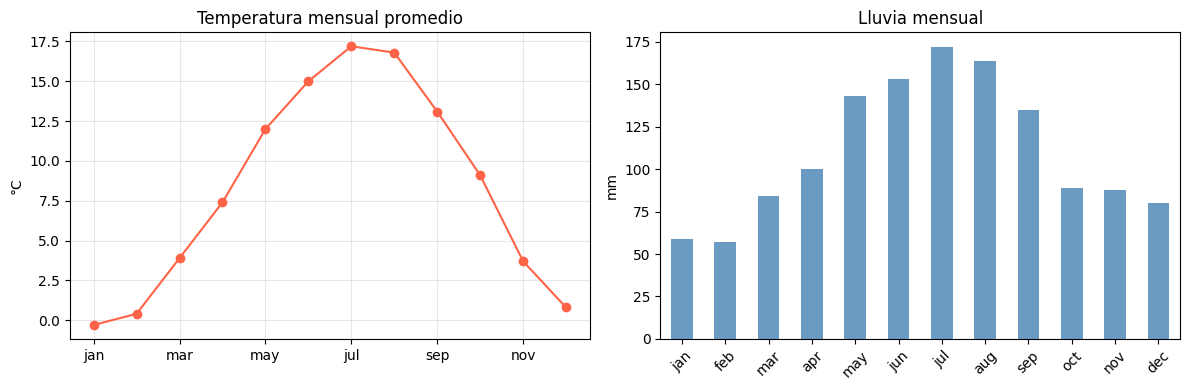

In [91]:
import matplotlib.pyplot as plt

# df.plot() — gráfica de línea (§8.5)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_clima['temp_C'].plot(kind='line', ax=axes[0], marker='o', color='tomato')
axes[0].set_title('Temperatura mensual promedio')
axes[0].set_ylabel('°C')
axes[0].grid(True, alpha=0.3)

df_clima['rain_mm'].plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Lluvia mensual')
axes[1].set_ylabel('mm')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

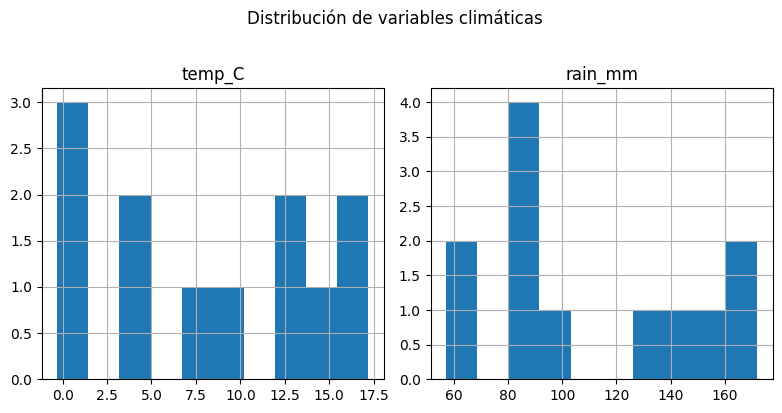

In [92]:
# df.hist() — histogramas de todas las columnas numéricas (§8.5)
df_clima.hist(figsize=(8, 4))
plt.suptitle('Distribución de variables climáticas', y=1.02)
plt.tight_layout()
plt.show()

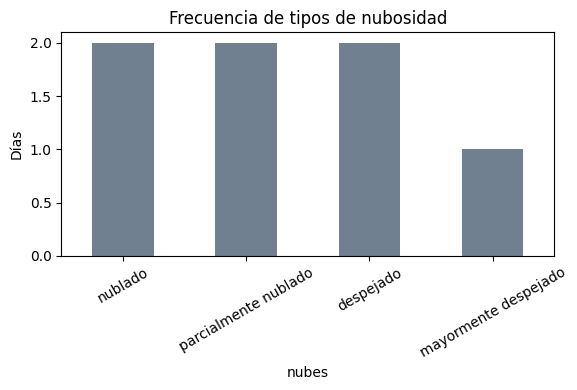

In [93]:
# value_counts().plot() — histograma de datos categóricos (§8.5)
fig, ax = plt.subplots(figsize=(6, 4))
df_cat['nubes'].value_counts().plot(kind='bar', ax=ax, color='slategray')
ax.set_title('Frecuencia de tipos de nubosidad')
ax.set_ylabel('Días')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
## Nivel 12 — Consejos de Pandas (§8.7)

In [94]:
# iterrows() — iterar sobre filas (§8.7)
print("Reporte climático mensual:")
for mes, datos in df_clima.iterrows():
    print(f"  {mes:>3}: {datos['temp_C']:5.1f}°C, {datos['rain_mm']:3.0f} mm de lluvia")

Reporte climático mensual:
  jan:  -0.3°C,  59 mm de lluvia
  feb:   0.4°C,  57 mm de lluvia
  mar:   3.9°C,  84 mm de lluvia
  apr:   7.4°C, 100 mm de lluvia
  may:  12.0°C, 143 mm de lluvia
  jun:  15.0°C, 153 mm de lluvia
  jul:  17.2°C, 172 mm de lluvia
  aug:  16.8°C, 164 mm de lluvia
  sep:  13.1°C, 135 mm de lluvia
  oct:   9.1°C,  89 mm de lluvia
  nov:   3.7°C,  88 mm de lluvia
  dec:   0.8°C,  80 mm de lluvia


In [95]:
# groupby() con condición booleana (§8.7)
print("Temperatura media según si llueve ≥ 100 mm:")
print(df_clima.groupby(df_clima['rain_mm'] >= 100)['temp_C'].mean().round(2))

Temperatura media según si llueve ≥ 100 mm:
rain_mm
False     2.93
True     13.58
Name: temp_C, dtype: float64


In [96]:
# Encadenar métodos — flujo de trabajo legible
resumen = (df_clima
    .assign(temp_F=lambda d: d['temp_C'] * 1.8 + 32)
    .loc[df_clima['temp_C'] > 10, ['temp_C', 'temp_F', 'rain_mm']]
    .sort_values('temp_C', ascending=False)
)
print("Meses cálidos (> 10°C):")
print(resumen)

Meses cálidos (> 10°C):
     temp_C  temp_F  rain_mm
jul    17.2   62.96      172
aug    16.8   62.24      164
jun    15.0   59.00      153
sep    13.1   55.58      135
may    12.0   53.60      143


---
## Ejercicios

### Ejercicio 1
Crea una Serie con los valores de precipitación mensual de tu ciudad.
Calcula: media, mediana, máximo y el mes con mayor precipitación (`argmax()`).

Enero           3
Febrero         5
Marzo           6
Abril          31
Mayo          129
Junio         272
Julio         203
Agosto        203
Septiembre    237
Octubre       132
Noviembre      49
Diciembre       7
dtype: int64

Promedio:   106.42
Mediana:    89.0
Màximo:     272
Mes con mayor precipitaciòn:   Junio


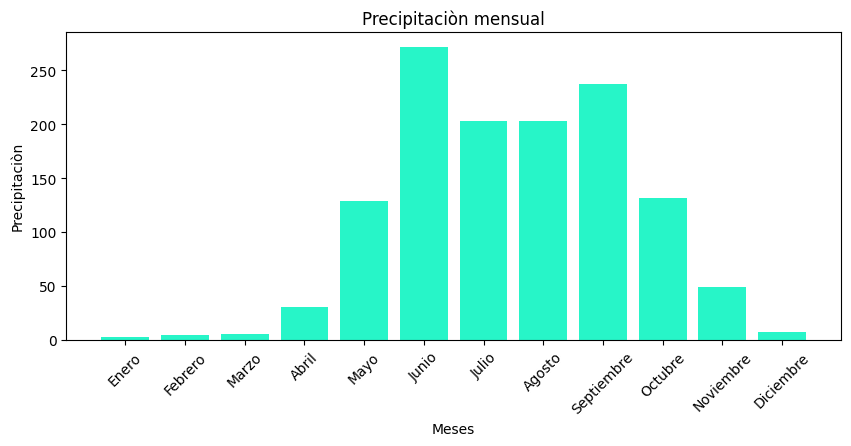

In [125]:
# TU CÓDIGO AQUÍ
# Fuente: https://www.weather-atlas.com/en/guatemala/guatemala-city-climate?utm_
#btw la precipitaciòn està en milìmetros
precipitacion_mensual = pd.Series(
    [3, 5, 6, 31, 129, 272, 203, 203, 237, 132, 49, 7],
    index=["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
)
print(precipitacion_mensual)
print("\nPromedio:  ", precipitacion_mensual.mean().round(2))
print("Mediana:   ", precipitacion_mensual.median())
print("Màximo:    ", precipitacion_mensual.max())
indice_del_mayor=precipitacion_mensual.idxmax()
print("Mes con mayor precipitaciòn:  ", indice_del_mayor)

# Le hice una gràfica nomàs porque sì
plt.figure(figsize=(10,4))
plt.bar(precipitacion_mensual.index, precipitacion_mensual.values, color="#27F5C8")
plt.title("Precipitaciòn mensual")
plt.xlabel("Meses")
plt.ylabel("Precipitaciòn")
plt.xticks(rotation=45)
plt.show()

### Ejercicio 2
Dado `df_clima`, filtra los meses con temperatura entre 5°C y 15°C.
Calcula la lluvia total en ese subconjunto.

In [130]:
# TU CÓDIGO AQUÍ
meses_entre_5_y_15 = df_clima[(df_clima["temp_C"] >= 5) & (df_clima["temp_C"] <= 15)]

lluvia_total = meses_entre_5_y_15["rain_mm"].sum()

print("La lluvia total es: ", lluvia_total, "mm.")

La lluvia total es:  620 mm.


### Ejercicio 3
Agrega al DataFrame `df_completo` (con `temp_min_C` y `temp_max_C`) una columna
`amplitud_termica = temp_max_C - temp_min_C`. Encuentra el mes con mayor amplitud.

In [145]:
# TU CÓDIGO AQUÍ
df_completo["amplitud_tèrmica"] = df_completo["temp_max_C"] - df_completo["temp_min_C"]
print(df_completo)
mes_mayor_amplitud = df_completo["amplitud"].idxmax()
print("Mes con mayor amplitud:  ", mes_mayor_amplitud)

     temp_C  rain_mm  temp_min_C  temp_max_C  amplitud  amplitud_tèrmica
jan    -0.3       59        -1.9         2.5       4.4               4.4
feb     0.4       57        -2.5         3.3       5.8               5.8
mar     3.9       84         0.6         7.3       6.7               6.7
apr     7.4      100         3.5        11.5       8.0               8.0
may    12.0      143         7.8        16.3       8.5               8.5
jun    15.0      153        11.0        19.2       8.2               8.2
jul    17.2      172        13.1        21.6       8.5               8.5
aug    16.8      164        13.0        20.9       7.9               7.9
sep    13.1      135         9.7        16.8       7.1               7.1
oct     9.1       89         6.2        12.3       6.1               6.1
nov     3.7       88         1.0         6.5       5.5               5.5
dec     0.8       80        -3.0         3.5       6.5               6.5
Mes con mayor amplitud:   jul


### Ejercicio 4
Crea un DataFrame con 5 estudiantes (nombre, nota1, nota2, nota3) con 3 valores NaN.  
a) Identifica cuántos NaN hay por columna.  
b) Rellena con la media de cada columna.  
c) Calcula la nota promedio final de cada estudiante.

In [158]:
# TU CÓDIGO AQUÍ
a5_estudiantes= pd.DataFrame(
{
    "Nombre": ["Josuè", "Dèbora", "Carlos", "Mìa", "Àngel"],
    "Nota 1": [8, np.nan, 7, 9, 9],
    "Nota 2": [7, 6, np.nan, 8, 9],
    "Nota 3": [9, 8, 6, 8, np.nan]
})
print(a5_estudiantes)
print("\nNùmero de nan por columna: \n", a5_estudiantes.isnull().sum())
a5_estudiantes["Nota 1"] = a5_estudiantes["Nota 1"].fillna(a5_estudiantes["Nota 1"].mean())
a5_estudiantes["Nota 2"] = a5_estudiantes["Nota 2"].fillna(a5_estudiantes["Nota 2"].mean())
a5_estudiantes["Nota 3"] = a5_estudiantes["Nota 3"].fillna(a5_estudiantes["Nota 3"].mean())
print("\n", a5_estudiantes, "\n")
a5_estudiantes["Nota promedio"] = a5_estudiantes[["Nota 1", "Nota 2", "Nota 3"]].mean(axis=1)

print(a5_estudiantes)

   Nombre  Nota 1  Nota 2  Nota 3
0   Josuè     8.0     7.0     9.0
1  Dèbora     NaN     6.0     8.0
2  Carlos     7.0     NaN     6.0
3     Mìa     9.0     8.0     8.0
4   Àngel     9.0     9.0     NaN

Nùmero de nan por columna: 
 Nombre    0
Nota 1    1
Nota 2    1
Nota 3    1
dtype: int64

    Nombre  Nota 1  Nota 2  Nota 3
0   Josuè    8.00     7.0    9.00
1  Dèbora    8.25     6.0    8.00
2  Carlos    7.00     7.5    6.00
3     Mìa    9.00     8.0    8.00
4   Àngel    9.00     9.0    7.75 

   Nombre  Nota 1  Nota 2  Nota 3  Nota promedio
0   Josuè    8.00     7.0    9.00       8.000000
1  Dèbora    8.25     6.0    8.00       7.416667
2  Carlos    7.00     7.5    6.00       6.833333
3     Mìa    9.00     8.0    8.00       8.333333
4   Àngel    9.00     9.0    7.75       8.583333


## Tarea 5 (opcional) — Pandas en Práctica

La programación se aprende haciendo. Esta tarea tiene dos partes:

**Parte 1 — Descarga y ejecuta** (obligatorio)
Descarga este notebook y ejecútalo celda por celda en tu computadora.  
Verifica que todas las celdas corran sin errores antes de continuar.

**Parte 2 — Ejercicios** (obligatorio)  
Resuelve los ejercicios de la sección anterior (Ejercicios 1 al 4).

**Parte 3 — Dataset real** (opcional, puntos extra)  
Descarga cualquier dataset CSV que te interese y aplica al menos 3 herramientas vistas:
lectura, limpieza, `groupby`, visualización.  
Agrega una celda Markdown con tus conclusiones.

**Entrega: 1 de mayo**  
Sube el notebook a tu repositorio de GitHub y envía el **link directo al archivo `.ipynb`**.
El notebook debe tener todas las celdas ya ejecutadas (con outputs visibles).

Ejemplo de link válido:  
`https://github.com/tu-usuario/tu-repo/blob/main/Pandas.ipynb`

Parte 5
Conclusiones: 

Considero que las gràficas son muy explicativas y tienen opciones para representar cualquier dataset o informaciòn en general, y se les puede cambiar el color y todo, y se ve muy bonito, eso me gusta bastante. Tambièn pandas es bastante ùtil para analizar cualquier lista o serie o conjunto de datos en general, y tiene maneras de simplificar lo que sea que se necesite hacer. Respecto al anàlisis del dataset de Iris, estaba bastante bien estructurado y la gràfica realizada de este dataset deja ver de una forma màs clara y visual los datos que son presentados. 


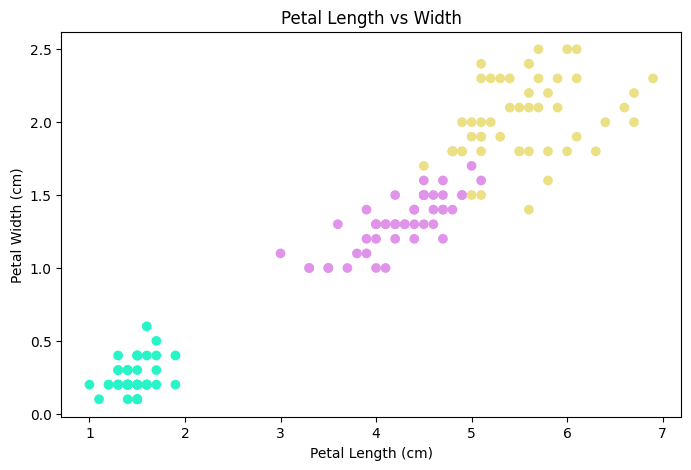


Lectura
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Limpieza
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [172]:
iris = pd.read_csv("Iris.csv")
import matplotlib.pyplot as plt
#visualizaciòn
colores = df["Species"].map({
    "Iris-setosa": "#27F5C8",
    "Iris-versicolor": "#DF94E9",
    "Iris-virginica": "#EBE084",
})

plt.figure(figsize=(8,5))
plt.scatter(df["PetalLengthCm"], df["PetalWidthCm"], c=colores)

plt.title("Petal Length vs Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.show()

#Lectura
print("\nLectura")
iris= pd.read_csv("Iris.csv")
print(iris.head())
#Limpieza
print("\nLimpieza")
print(df.dtypes)
print(df.isnull().sum())